# 🔬 BioSLATE Project — Phase 2 & 3: Synthetic Lethal Target Discovery

**Author:** Faith Ogundimu  
**Date:** June 2025

**Notebook Purpose:**
This notebook sets the foundation for identifying synthetic lethal interactions in High-Grade Serous Ovarian Cancer (HGSOC) cell lines. Using gene effect scores from DepMap CRISPR screens (Chronos), we aim to determine which genes become essential when specific genomic biomarkers (e.g., BRCA1 deletion) are present. These biomarkers were defined through cross-validation between TCGA tumours and DepMap cell lines (Phase 1).

> **Context:** This analysis builds directly on the biomarker shortlists from Phase 1, where amplified and deleted genes were cross-validated between TCGA tumours and HGSOC cell lines.
> Here, we test whether these CNA biomarkers can stratify cell lines in a way that reveals context-specific gene dependencies.

### 🎯 Objectives:
* Group HGSOC cell lines based on the presence or absence of validated CNA biomarkers (e.g., BRCA1 deletion).
* For each group, compare CRISPR gene effect scores to identify genes that are **synthetically lethal** only in biomarker-positive lines.
* Perform statistical tests (e.g., Welch’s t-test) to assess significance.
* Adjust for multiple testing using False Discovery Rate (FDR) correction.
* Prioritise biomarker–target pairs with strong effect sizes and high confidence for therapeutic relevance.


In [1]:
import pandas as pd

# read in file
crispr_df = pd.read_csv("/Users/faith/Documents/GitHub/bioslate-hgsoc-core/database_files/DepMap/CRISPRGeneEffect.csv", index_col=0)
# This will make 'ACH-000628', 'ACH-000974', etc., become the row index (instead of just Row 0, Row 1, ...).

In [2]:
crispr_df

,A1BG (1),A1CF (29974),A2M (2),A2ML1 (144568),A3GALT2 (127550),A4GALT (53947),A4GNT (51146),AAAS (8086),AACS (65985),AADAC (13),...,ZWILCH (55055),ZWINT (11130),ZXDA (7789),ZXDB (158586),ZXDC (79364),ZYG11A (440590),ZYG11B (79699),ZYX (7791),ZZEF1 (23140),ZZZ3 (26009)
ACH-000001,-0.121964,0.042647,0.026102,-0.147614,-0.020425,0.184014,-0.076020,-0.097068,0.182759,-0.002365,...,-0.120536,0.107286,0.166390,0.262275,0.163876,-0.249508,0.053725,0.067986,0.136285,-0.438536
ACH-000004,-0.016484,-0.088500,-0.088198,-0.041225,-0.028074,-0.157206,0.280101,-0.106904,0.178125,0.149760,...,-0.192527,-0.324059,0.230377,0.087609,0.074897,0.054335,-0.330343,0.099067,0.274566,0.001871
ACH-000005,-0.184847,0.003300,0.160881,0.086224,-0.149315,-0.253837,0.167011,-0.101209,-0.129827,0.029143,...,-0.312827,-0.338023,-0.039700,-0.055349,-0.000367,-0.205605,-0.066032,-0.054518,0.035579,-0.150486
ACH-000007,-0.071921,-0.113717,0.082872,0.099633,-0.008378,-0.022310,0.014416,-0.184977,-0.173739,0.196363,...,-0.334843,-0.355499,-0.014183,0.230944,0.044628,-0.081863,-0.390748,-0.036547,-0.273129,-0.382723
ACH-000009,-0.019163,-0.134669,0.060323,0.076647,0.078922,-0.100243,0.047559,-0.136988,0.037759,0.093207,...,-0.299593,-0.194427,-0.027365,0.236591,-0.084224,-0.098271,-0.510495,0.052938,0.018623,-0.258353
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACH-002926,-0.107883,-0.101501,0.046677,0.096868,-0.118650,-0.065258,-0.064944,-0.175912,-0.044707,0.126244,...,-0.409541,-0.579376,0.038706,0.338610,-0.174379,-0.040264,-0.239763,0.065168,-0.144088,-0.334424
ACH-002928,-0.287606,-0.179101,-0.135824,-0.046579,-0.249888,-0.097376,0.070385,0.049444,-0.244937,0.058041,...,-0.095328,-0.440452,0.303500,0.097690,0.151790,0.039994,0.098240,-0.266654,-0.115108,-0.080421
ACH-003012,-0.145878,-0.004000,0.091933,0.191332,-0.065385,-0.134152,0.012353,-0.321012,0.001571,0.146177,...,-0.280119,-0.662673,-0.180936,0.169997,-0.036326,0.158702,-0.213281,-0.017884,-0.195395,-0.309021
ACH-003177,-0.038435,-0.055660,0.018989,0.117182,0.063397,0.049993,0.175520,-0.085752,0.078435,0.089513,...,-0.080700,-0.476797,-0.158375,-0.008999,-0.030058,-0.103513,-0.119234,-0.153744,0.032584,-0.536071


### 🧬 What is the "CRISPR Gene Effect" (Chronos)?

- Each **value** reflects how essential a gene is for a given **cell line's survival**.
- **Lower scores** (closer to –1) = **higher dependency** (i.e. gene knockout causes cell death).
- **Score ~ 0** = knockout has little to no effect.
- Chronos is an updated model designed to better estimate **gene knockout effects** from CRISPR screens, especially in **non-dividing or slow-growing** cells.

| **Gene Effect Score** | **Interpretation** |
| --- | --- |
| ~–1.0 | Strong dependency |
| ~0.0 | No effect |
| > 0.0 | Possibly beneficial knock-out (rare) |

In [3]:
hgsoc_cell_lines = pd.read_csv("/Users/faith/Documents/GitHub/bioslate-hgsoc-core/database_files/DepMap/cell lines in High-Grade Serous Ovarian Cancer.csv")
# The first row is treated as the header (column names) by default. (explicit; header=0)

hgsoc_cell_lines

,Depmap Id,Cell Line,Primary Disease,Tumor Type
0,ACH-000132,JHOS2,Ovarian Epithelial Tumor,Primary
1,ACH-002183,OVMIU,Ovarian Epithelial Tumor,NaN
2,ACH-001151,OVCAR5,Ovarian Epithelial Tumor,Metastatic
3,ACH-000635,SNU119,Ovarian Epithelial Tumor,Metastatic
4,ACH-000430,TYKNU,Ovarian Epithelial Tumor,Primary
5,ACH-002140,HEY,Ovarian Epithelial Tumor,Primary
6,ACH-000103,CAOV4,Ovarian Epithelial Tumor,Metastatic
7,ACH-000001,NIHOVCAR3,Ovarian Epithelial Tumor,Metastatic
8,ACH-000256,COV318,Ovarian Epithelial Tumor,Metastatic
9,ACH-000542,HEYA8,Ovarian Epithelial Tumor,Metastatic


In [4]:
# Get the intersection of cell lines present in both hgsoc_cell_lines and crispr
valid_ids = hgsoc_cell_lines["Depmap Id"].isin(crispr_df.index) # returns boolean
shared_ids = hgsoc_cell_lines.loc[valid_ids, "Depmap Id"] # returns indexed list.

# Now use this list to filter crispr
crispr_filtered = crispr_df.loc[shared_ids]

In [5]:
crispr_filtered.columns = crispr_filtered.columns.str.extract(r"\((\d+)\)")[0].astype(str)
# ['ACH-000635', 'ACH-000409', 'ACH-000574', 'ACH-000617', 'ACH-000443'] not in crispr file.

### CRISPR File 

In [6]:
crispr_filtered

,1,29974,2,144568,127550,53947,51146,8086,65985,13,...,55055,11130,7789,158586,79364,440590,79699,7791,23140,26009
ACH-000132,-0.122873,0.072059,0.038849,0.039049,-0.209066,0.076330,-0.094047,-0.009645,-0.031795,0.202345,...,-0.131236,-0.471731,0.029672,0.012413,-0.127275,0.018842,-0.164656,-0.155827,-0.115392,-0.650192
ACH-002183,-0.245112,-0.053354,0.071037,0.337962,-0.109942,-0.013398,0.303089,0.046424,0.200121,0.492939,...,-0.405278,-0.548039,0.075445,-0.046378,-0.319488,-0.146330,-0.352998,-0.081459,-0.191924,-0.215067
ACH-001151,-0.102453,-0.077385,-0.019409,0.028298,-0.160307,-0.056900,0.039573,-0.268167,0.002770,0.096360,...,-0.119769,-0.217415,0.016761,0.170917,-0.044003,-0.095041,-0.187164,-0.083624,-0.176731,-0.417039
ACH-000430,-0.084244,0.058017,-0.053142,0.198323,-0.072941,-0.206886,0.122309,-0.018023,-0.105048,0.214323,...,-0.023189,-0.538709,0.027976,0.119626,-0.031476,-0.021702,-0.215309,-0.333313,-0.015074,-0.006619
ACH-002140,-0.104728,0.110308,-0.025987,0.257998,0.108899,-0.154841,0.001961,-0.214199,0.055091,0.245402,...,-0.665836,-0.157587,0.073392,-0.048359,-0.063494,-0.012150,-0.228079,-0.016597,-0.187425,-0.560568
ACH-000103,-0.294804,0.065371,-0.063194,0.072800,-0.072182,0.159779,0.236855,0.137420,-0.244539,0.331102,...,-0.269222,-0.593750,0.108921,-0.102701,-0.173919,0.045712,-0.208987,0.035390,-0.158814,0.033504
ACH-000001,-0.121964,0.042647,0.026102,-0.147614,-0.020425,0.184014,-0.076020,-0.097068,0.182759,-0.002365,...,-0.120536,0.107286,0.166390,0.262275,0.163876,-0.249508,0.053725,0.067986,0.136285,-0.438536
ACH-000256,-0.198217,-0.046660,0.050505,0.029620,-0.062260,-0.002114,0.278037,-0.293802,-0.109867,0.157249,...,-0.304890,-0.471835,-0.124134,0.080740,0.161809,0.089320,0.025617,-0.091058,0.117985,-0.217564
ACH-000542,-0.135195,-0.012998,0.106194,0.150954,0.033209,-0.006644,-0.015868,-0.542180,-0.093912,0.089950,...,-0.321037,-0.365938,0.045471,0.107203,-0.067005,0.014995,-0.359367,-0.094584,-0.216769,-0.449894
ACH-000696,-0.014307,-0.008415,0.023248,0.063404,-0.050467,-0.005701,-0.025869,-0.297252,-0.071535,0.081685,...,-0.179381,-0.542944,0.105737,-0.027614,-0.185295,-0.033858,-0.113058,-0.103185,-0.238914,-0.439584


In [20]:
sig_effect_size_per_cell_line = (crispr_filtered < -0.6).sum(axis=1)
print(f"Number of genes with mean effect size < –0.6 across all cell lines:\n{sig_effect_size_per_cell_line}")

Number of genes with mean effect size < –0.6 across all cell lines:
ACH-000132    1491
ACH-002183    1536
ACH-001151    1551
ACH-000430    1628
ACH-002140    1447
ACH-000103    1419
ACH-000001    1441
ACH-000256    1384
ACH-000542    1510
ACH-000696    1652
ACH-000524    1415
ACH-000116    1482
ACH-000520    1412
ACH-000278    1446
ACH-000584    1488
ACH-000713    1477
ACH-000013    1523
ACH-001628    1460
dtype: int64


### Group HGSOC cell lines based on the presence or absence of validated CNA biomarkers (e.g., BRCA1 deletion)

In [8]:
# Read in candidate deleted biomarkers.
cna_hgsoc_depmap = pd.read_csv("/Users/faith/Documents/GitHub/bioslate-hgsoc-core/results/cna_depmap_hgsoc.csv", index_col=0)

In [9]:
cna_hgsoc_depmap

,6009,54962,403253,55746,107984504,9601,106479964,730100,113523638,619448,...,8897,106480863,388181,106481503,100302218,53827,100873420,84910,106480139,106480076
ACH-000132,3.0,2.0,4.0,3.0,4.0,3.0,4.0,4.0,3.0,4.0,...,3.0,1.0,4.000000,4.00000,2.0,4.0,2.0,3.0,4.0,4.0
ACH-002183,2.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,3.0,2.000000,2.00000,2.0,2.0,2.0,2.0,2.0,2.0
ACH-001151,2.0,3.0,3.0,2.0,2.0,2.0,3.0,3.0,2.0,2.0,...,2.0,2.0,3.000000,2.00000,2.0,2.0,2.0,3.0,3.0,4.0
ACH-000635,4.0,2.0,3.0,4.0,4.0,4.0,3.0,3.0,3.0,2.0,...,2.0,3.0,2.000000,2.00000,4.0,4.0,2.0,4.0,3.0,3.0
ACH-000430,4.0,2.0,3.0,3.0,2.0,4.0,3.0,3.0,2.0,2.0,...,2.0,3.0,2.000000,2.00000,4.0,2.0,2.0,3.0,2.0,2.0
ACH-002140,1.0,3.0,4.0,3.0,4.0,1.0,4.0,4.0,4.0,4.0,...,3.0,3.0,3.000000,5.00000,2.0,4.0,3.0,4.0,5.0,5.0
ACH-000103,3.0,2.0,2.0,4.0,3.0,3.0,2.0,3.0,3.0,2.0,...,2.0,2.0,2.000000,2.00000,3.0,4.0,3.0,3.0,3.0,3.0
ACH-000001,3.0,4.0,4.0,4.0,6.0,3.0,4.0,3.0,4.0,4.0,...,4.0,4.0,2.000000,4.00000,3.0,6.0,5.0,3.0,4.0,6.0
ACH-000256,6.0,3.0,2.0,5.0,4.0,6.0,4.0,5.0,3.0,3.0,...,3.0,5.0,3.000000,3.00000,6.0,7.0,3.0,4.0,3.0,3.0
ACH-000542,2.0,3.0,5.0,3.0,5.0,2.0,4.0,4.0,4.0,5.0,...,3.0,3.0,3.000000,5.00000,2.0,4.0,4.0,4.0,5.0,5.0


In [12]:
# Read in candidate deleted biomarkers.
amp_biomarkers = pd.read_csv("/Users/faith/Documents/GitHub/bioslate-hgsoc-core/results/cross_val_amp_sig_genes.csv", index_col=1)

In [13]:
amp_biomarkers = amp_biomarkers.index.astype(str)
amp_biomarkers

Index(['10016', '1004', '10048', '10049', '10051', '10054', '10059', '10061',
       '10067', '10139',
       ...
       '9791', '9817', '9828', '9846', '9847', '9869', '9873', '9885', '9967',
       '9972'],
      dtype='object', name='Gene', length=698)

In [14]:
# Getting CNA info only for the cross validated biomarkers from Step 2.
# This will then be tested against the crispr gene effect file.

cna_hgsoc_depmap = cna_hgsoc_depmap.transpose()
cna_hgsoc_depmap_filtered = cna_hgsoc_depmap.loc[amp_biomarkers]

In [15]:
cna_hgsoc_depmap_filtered
# Genes are index

,ACH-000132,ACH-002183,ACH-001151,ACH-000635,ACH-000430,ACH-002140,ACH-000103,ACH-000001,ACH-000256,ACH-000542,...,ACH-000696,ACH-000574,ACH-000524,ACH-000116,ACH-000520,ACH-000278,ACH-000584,ACH-000013,ACH-001628,ACH-000443
Gene,,,,,,,,,,,,,,,,,,,,,
10016,3.0,2.0,3.0,6.0,3.0,4.0,6.000000,4.0,4.0,5.0,...,3.0,4.0,6.0,4.0,5.0,2.0,3.0,5.0,7.0,3.0
1004,3.0,2.0,2.0,3.0,3.0,4.0,4.000000,4.0,4.0,5.0,...,3.0,4.0,8.0,6.0,4.0,2.0,3.0,4.0,6.0,3.0
10048,3.0,2.0,2.0,3.0,2.0,3.0,3.000000,3.0,4.0,4.0,...,4.0,3.0,5.0,3.0,3.0,2.0,3.0,2.0,6.0,1.0
10049,5.0,2.0,2.0,4.0,4.0,1.0,3.000000,3.0,6.0,2.0,...,3.0,3.0,6.0,4.0,2.0,3.0,5.0,3.0,3.0,2.0
10051,7.0,3.0,4.0,4.0,3.0,6.0,3.000000,7.0,5.0,7.0,...,2.0,4.0,4.0,7.0,2.0,2.0,5.0,7.0,4.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9869,5.0,4.0,3.0,6.0,3.0,4.0,9.780668,3.0,5.0,4.0,...,2.0,4.0,5.0,3.0,3.0,3.0,4.0,2.5,5.0,3.0
9873,4.0,2.0,3.0,4.0,3.0,4.0,2.000000,8.0,5.0,4.0,...,3.0,4.0,4.0,4.0,3.0,4.0,5.0,8.0,4.0,3.0
9885,7.0,4.0,3.0,3.0,3.0,5.0,6.000000,6.0,7.0,6.0,...,3.0,4.0,7.0,2.0,3.0,2.0,5.0,5.0,5.0,3.0


### CNA File

In [16]:
cna_hgsoc_depmap_filtered = cna_hgsoc_depmap_filtered.transpose()
cna_hgsoc_depmap_filtered

Gene,10016,1004,10048,10049,10051,10054,10059,10061,10067,10139,...,9791,9817,9828,9846,9847,9869,9873,9885,9967,9972
ACH-000132,3.0,3.0,3.0,5.0,7.0,4.0,4.0,3.0,5.0,7.0,...,4.0,4.0,4.0,6.000000,6.0,5.000000,4.0,7.0,5.0,3.0
ACH-002183,2.0,2.0,2.0,2.0,3.0,2.0,2.0,2.0,4.0,3.0,...,2.0,2.0,2.0,2.000000,2.0,4.000000,2.0,4.0,2.0,2.0
ACH-001151,3.0,2.0,2.0,2.0,4.0,2.0,2.0,2.0,3.0,3.0,...,4.0,2.0,3.0,3.000000,2.0,3.000000,3.0,3.0,2.0,2.0
ACH-000635,6.0,3.0,3.0,4.0,4.0,4.0,3.0,4.0,5.0,3.0,...,6.0,3.0,4.0,5.000000,3.0,6.000000,4.0,3.0,3.0,3.0
ACH-000430,3.0,3.0,2.0,4.0,3.0,2.0,2.0,4.0,3.0,3.0,...,3.0,2.0,3.0,3.000000,2.0,3.000000,3.0,3.0,4.0,2.0
ACH-002140,4.0,4.0,3.0,1.0,6.0,4.0,6.0,1.0,4.0,5.0,...,7.0,3.0,4.0,4.000000,6.0,4.000000,4.0,5.0,3.0,3.0
ACH-000103,6.0,4.0,3.0,3.0,3.0,4.0,3.0,3.0,5.0,6.0,...,2.0,2.0,2.0,2.000000,3.0,9.780668,2.0,6.0,3.0,3.0
ACH-000001,4.0,4.0,3.0,3.0,7.0,6.0,5.0,3.0,6.0,6.0,...,4.0,3.0,8.0,13.413596,7.0,3.000000,8.0,6.0,3.0,3.0
ACH-000256,4.0,4.0,4.0,6.0,5.0,7.0,4.0,6.0,5.0,7.0,...,2.0,5.0,5.0,5.000000,3.0,5.000000,5.0,7.0,5.0,4.0
ACH-000542,5.0,5.0,4.0,2.0,7.0,4.0,6.0,2.0,4.0,6.0,...,8.0,4.0,4.0,5.000000,6.0,4.000000,4.0,6.0,3.0,4.0


## 🧬 Synthetic Lethality Screen: Amplified Biomarkers vs CRISPR Dependencies

This code performs a biomarker-driven synthetic lethality screen using CRISPR dependency data across HGSOC cell lines.

### 🔍 Key Steps

1. **Amplification Status Assignment**
   - For each amplified biomarker gene (based on `amp_threshold = 4`), label cell lines as either `"Amplified"` or `"WT"`.  


2. **CRISPR Dependency Comparison**
   - For each biomarker:
     - Divide cell lines into Amplified vs WT groups.
     - For every CRISPR-targeted gene:
       - Only test genes that are **strongly essential** overall (`mean ≤ –0.6`).
       - Run **Welch’s t-test** comparing knockout scores between groups.
       - Compute **Cohen’s d effect size**.
       - Flag `OncogeneAddiction` if `Biomarker == TargetGene`.  


3. **Multiple Testing Correction**
   - Apply **Benjamini–Hochberg FDR correction** within each biomarker’s comparisons.


In [17]:
# 698 biomarkers × 17,916 genes (much less for Effect Size < -0.6) = ~12.5 million biomarker–target comparisons

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

# Parameters
amp_threshold = 4.0  # Amplification cutoff for absolute CN
min_group_size = 3
effect_threshold = -0.6  # Strong dependency = more negative

# --- Step 1: Generate CNA status matrix for amplified biomarkers only ---
status_dict = {}

for gene in amp_biomarkers:
    if gene in cna_hgsoc_depmap_filtered.columns:
        status_dict[f"{gene}_status"] = cna_hgsoc_depmap_filtered[gene].apply(
            lambda x: "Amplified" if x > amp_threshold else "WT"
        )

cna_status_df = pd.DataFrame(status_dict, index=cna_hgsoc_depmap_filtered.index)

# --- Step 2: Loop through biomarkers and perform CRISPR comparisons ---
results = []

for biomarker in amp_biomarkers:
    biomarker_col = f"{biomarker}_status"
    if biomarker_col not in cna_status_df.columns:
        continue

    amp_lines = cna_status_df[cna_status_df[biomarker_col] == "Amplified"].index
    wt_lines = cna_status_df[cna_status_df[biomarker_col] == "WT"].index

    amp_lines = [line for line in amp_lines if line in crispr_filtered.index]
    wt_lines = [line for line in wt_lines if line in crispr_filtered.index]

    if len(amp_lines) < min_group_size or len(wt_lines) < min_group_size:
        continue

    for gene in crispr_filtered.columns:
        # Skip genes that are not essential enough
        if crispr_filtered[gene].mean() > effect_threshold:
            continue

        group_amp = crispr_filtered.loc[amp_lines, gene].dropna()
        group_wt = crispr_filtered.loc[wt_lines, gene].dropna()

        if len(group_amp) < min_group_size or len(group_wt) < min_group_size:
            continue

        t_stat, p_val = ttest_ind(group_amp, group_wt, equal_var=False)
        pooled_sd = np.sqrt(((group_amp.std(ddof=1)**2 + group_wt.std(ddof=1)**2) / 2))
        effect_size = (group_amp.mean() - group_wt.mean()) / pooled_sd if pooled_sd > 0 else np.nan

        results.append({
            "Biomarker": biomarker,
            "TargetGene": gene,
            "OncogeneAddiction": biomarker == gene,
            "T-stat": t_stat,
            "P-value": p_val,
            "EffectSize": effect_size,
            "n_Amplified": len(group_amp),
            "n_WT": len(group_wt),
            "MeanEffect_Amplified": group_amp.mean(),
            "MeanEffect_WT": group_wt.mean()
        })

# --- Step 3: Convert to DataFrame ---
results_df = pd.DataFrame(results)

# --- Step 4: FDR correction (per biomarker) ---
results_df["FDR"] = results_df.groupby("Biomarker")["P-value"].transform(
    lambda p: multipletests(p, method="fdr_bh")[1]
)

# --- Step 5: Save ---
results_df.to_csv("../results/synthetic_lethality_screen.csv", index=False)

In [18]:
results_df.shape

(728355, 11)

In [23]:
# Count number of oncogene addictions.
oncogene_addict_counts = results_df["OncogeneAddiction"].sum()
oncogene_addict_counts

# "OncogeneAddiction" is already a Boolean column.
# .sum() on a Boolean Series counts how many True values exist.

80

### Filter Most Significant Hits

In [25]:
import pandas as pd

# Load results
results_df = pd.read_csv("../results/synthetic_lethality_screen.csv")

# Filter 1: P-value < 0.05
pval_hits = results_df[results_df["P-value"] < 0.05]
pval_hits.to_csv("../results/significant_synthetic_hits_pval.csv", index=False)

# Filter 2: FDR < 0.05
fdr_hits = results_df[results_df["FDR"] < 0.05]
fdr_hits.to_csv("../results/significant_synthetic_hits_fdr.csv", index=False)

# Filter 3: Strong & significant SL hits
# Criteria: FDR < 0.05 AND EffectSize < 0
sl_hits_strong = results_df[
    (results_df["FDR"] < 0.05) &
    (results_df["EffectSize"] < 0)
]
sl_hits_strong.to_csv("../results/strong_synthetic_lethal_hits.csv", index=False)

# Print summary
print(f"P-value < 0.05: {len(pval_hits)} hits")
print(f"FDR < 0.05: {len(fdr_hits)} hits")
print(f"Strong SL hits (FDR < 0.05 & EffectSize < 0): {len(sl_hits_strong)} hits")

P-value < 0.05: 41104 hits
FDR < 0.05: 238 hits
Strong SL hits (FDR < 0.05 & EffectSize < 0): 90 hits


### 📊 **Volcano Plot vs Heatmap Summary**

| Feature           | Volcano Plot                                             | Heatmap                                                         |
| ----------------- | -------------------------------------------------------- | --------------------------------------------------------------- |
| **What it shows** | Strength + significance of each biomarker–target pair    | Global dependency patterns across biomarkers                    |
| **X-axis**        | Effect size (Cohen’s d)                                  | Biomarker gene (columns)                                        |
| **Y-axis**        | –log₁₀(FDR)                                              | Target gene (rows)                                              |
| **Highlights**    | Top hits: SL pairs with large negative effects + low FDR | Repeatedly essential genes, co-dependencies, oncogene addiction |
| **Use case**      | Identify top hits per biomarker                          | Spot patterns, redundancies, shared vulnerabilities             |



## 📈 Volcano Plot: Visualising Strength vs Significance of SL Hits

The volcano plot helps visualise **synthetic lethal interactions** by combining:

- **Effect size** (Cohen’s d): how much more lethal a gene knockout is in amplified vs wild-type lines
- **Statistical significance** (FDR): confidence in the result

### 🔍 What it shows:
- **X-axis**: Effect size (negative values = stronger synthetic lethality)
- **Y-axis**: –log₁₀(FDR) (higher = more statistically significant)
- Each point = one biomarker–target gene pair

### ✅ Why it's important:
- Highlights **top SL hits**: genes with **strong negative effects** and **low FDR**
- Easily distinguishes:
  - True positives (top-left)
  - Noise (bottom center)
  - Oncogene addiction
  
- Fast way to prioritise genes for validation or drug targeting


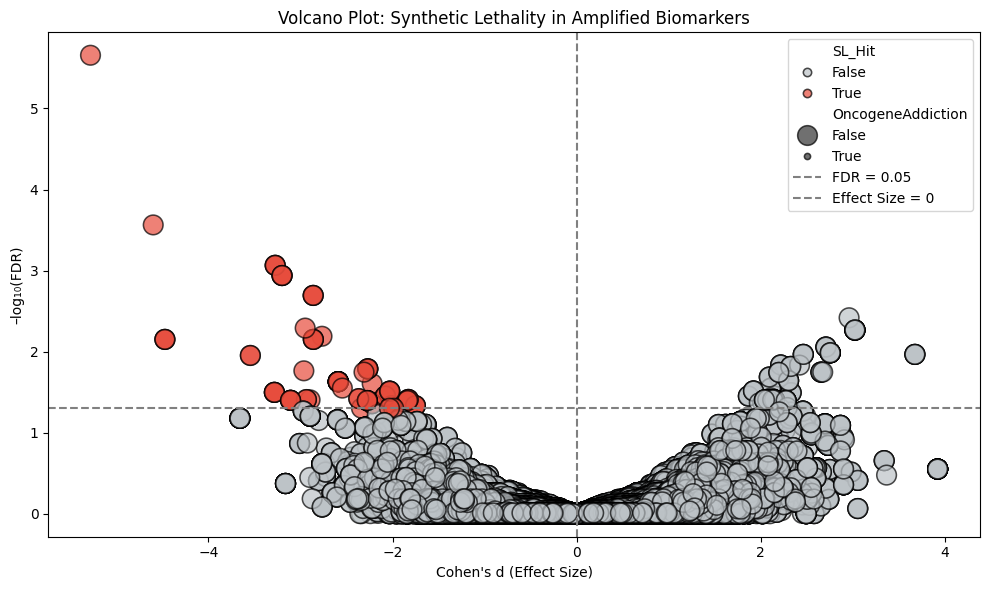

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load results
results_df = pd.read_csv("../results/synthetic_lethality_screen.csv")

# Add significance threshold
results_df["–log10(FDR)"] = -np.log10(results_df["FDR"] + 1e-10)  # avoid log(0)

# Define SL hit
results_df["SL_Hit"] = (results_df["EffectSize"] < 0) & (results_df["FDR"] < 0.05)
results_df["OncogeneAddiction"] = results_df["Biomarker"] == results_df["TargetGene"]

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=results_df,
    x="EffectSize",
    y="–log10(FDR)",
    hue="SL_Hit",
    size="OncogeneAddiction",
    sizes=(20, 200),
    palette={True: "#e74c3c", False: "#bdc3c7"},
    alpha=0.7,
    edgecolor="black"
)
plt.axhline(y=-np.log10(0.05), linestyle="--", color="gray", label="FDR = 0.05")
plt.axvline(x=0, linestyle="--", color="gray", label="Effect Size = 0")
plt.xlabel("Cohen's d (Effect Size)")
plt.ylabel("–log₁₀(FDR)")
plt.title("Volcano Plot: Synthetic Lethality in Amplified Biomarkers")
plt.legend()
plt.tight_layout()
plt.show()

## 🧬 2. **Heatmap**

### 🎯 **Purpose:**

Show **patterns of gene dependencies across multiple biomarkers**, helping identify:

* Repeated vulnerabilities (e.g. “this gene is SL with many amplifications”)
* Gene modules or pathway-level effects

---

### 🧠 **What It Shows:**

| Axis        | What’s Shown                                              |
| ----------- | --------------------------------------------------------- |
| **Rows**    | Target genes                                              |
| **Columns** | Amplified biomarkers                                      |
| **Cells**   | Cohen’s d, Mean effect in amplified lines, or –log₁₀(FDR) |

---

### 💥 **What You Can Spot:**

* **Horizontal bands** = genes that are SL with many biomarkers
* **Vertical bands** = biomarkers with many dependencies
* **Dark cells** = strong SL effects (e.g., `EffectSize < 0`)

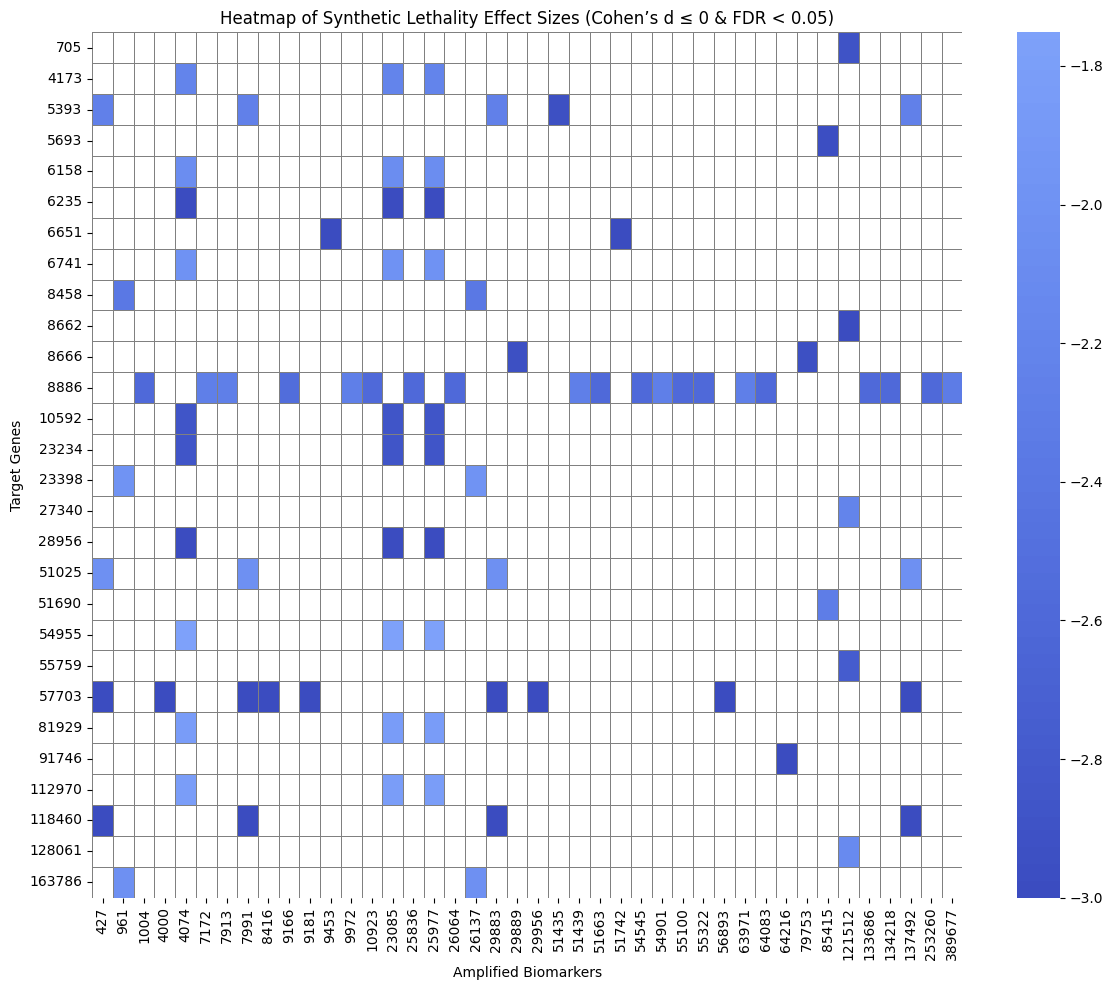

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot: rows = target genes, cols = biomarkers, values = Effect Size
heatmap_df = results_df[
    (results_df["EffectSize"] < 0) & (results_df["FDR"] < 0.05)
].pivot(index="TargetGene", columns="Biomarker", values="EffectSize")

# Optional: cap extreme values
capped = heatmap_df.clip(-3, 0)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(capped, cmap="coolwarm", center=0, linewidths=0.5, linecolor="gray")
plt.title("Heatmap of Synthetic Lethality Effect Sizes (Cohen’s d ≤ 0 & FDR < 0.05)")
plt.xlabel("Amplified Biomarkers")
plt.ylabel("Target Genes")
plt.tight_layout()
plt.show()